# 235 - Graded decomposition (convex NMF)

**Figures F3-F5.** Every electrode gets a weight on every component instead of one label.

Convex NMF because it accepts **signed** data - high-gamma in baseline-relative dB goes negative, which ordinary NMF cannot take. Same method as Hamilton 2018/2021, Kurteff 2024 and Norman-Haignere 2022 on this data type.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, "functions")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import lf_decompose as D

RUN = Path("outputs/clustering/hierarchical/concat_rawds/runs/20260817_171733")
OUT = Path("outputs/clustering/decomposition"); OUT.mkdir(parents=True, exist_ok=True)

X    = np.load(RUN / "X_train.npy").astype(np.float64)
lab  = pd.read_csv(RUN / "labels.csv")
CCOL = next(c for c in lab.columns if c.startswith("cluster_") and not c.endswith("_ranked"))
y5   = lab[CCOL].to_numpy()
pat  = lab["patient_id"].astype(str).to_numpy()

# fsaverage coordinates, for anatomical coherence
_co = pd.read_csv("outputs/250_recon/fsaverage/coords/ALL_PATIENTS_contacts_fsaverage.csv")
_nz = lambda s: str(s).replace("_", "").replace("-", "").upper()
_co["key"] = [f"{p}|{_nz(x)}" for p, x in zip(_co["patient"], _co["name"])]
lab["key"] = [f"{p}|{_nz(e)}" for p, e in zip(lab["patient_id"], lab["electrode"])]
XYZ = lab.merge(_co[["key", "x", "y", "z"]], on="key", how="left")[["x", "y", "z"]].to_numpy()

CONDS = ["audio", "picture", "reading"]; NT = X.shape[1] // 3
print(f"{X.shape[0]} electrodes x {X.shape[1]} features | {len(np.unique(pat))} patients "
      f"| {np.isnan(XYZ).any(1).sum()} without coordinates")

1266 electrodes x 1350 features | 27 patients | 231 without coordinates


## 1 - How many components? Held-out reconstruction

Fit without a fold of electrodes, project that fold onto the fitted components, measure the error. Unlike silhouette this **can get worse** when the rank is too high, so it is a real criterion (Norman-Haignere 2022).

*Slow - a few minutes. Narrow `KS` while exploring.*

,mean,std
k,,
2,0.2621,0.0090
3,0.3249,0.0164
4,0.3708,0.0165
5,0.4032,0.0158
6,0.4251,0.0145
8,0.4639,0.0126
10,0.4915,0.0100
12,0.5171,0.0109
14,0.5336,0.0137


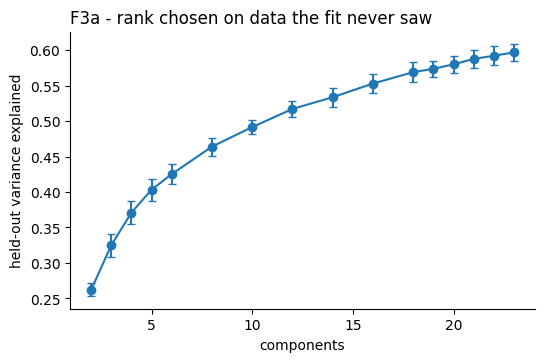

In [2]:
Xs = D.unit_norm(X)
KS = [2, 3, 4, 5, 6, 8, 10, 12, 14,16,18,19,20,21,22,23]
cv = D.cv_rank_curve(Xs, KS, n_folds=5, n_iter=150)
g  = cv.groupby("k")["var_explained"].agg(["mean", "std"])
display(g.round(4))

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.errorbar(g.index, g["mean"], yerr=g["std"], marker="o", capsize=3)
ax.set_xlabel("components"); ax.set_ylabel("held-out variance explained")
ax.set_title("F3a - rank chosen on data the fit never saw", loc="left")
ax.spines[["top", "right"]].set_visible(False)
fig.savefig(OUT / "F3a_cv_rank.png", dpi=150, bbox_inches="tight"); plt.show()

## 2 - The components

Set `K` from the curve above. Each component is a weighted average of real electrodes, so it is a response profile in dB that you can read directly.

in-sample variance explained: 0.404


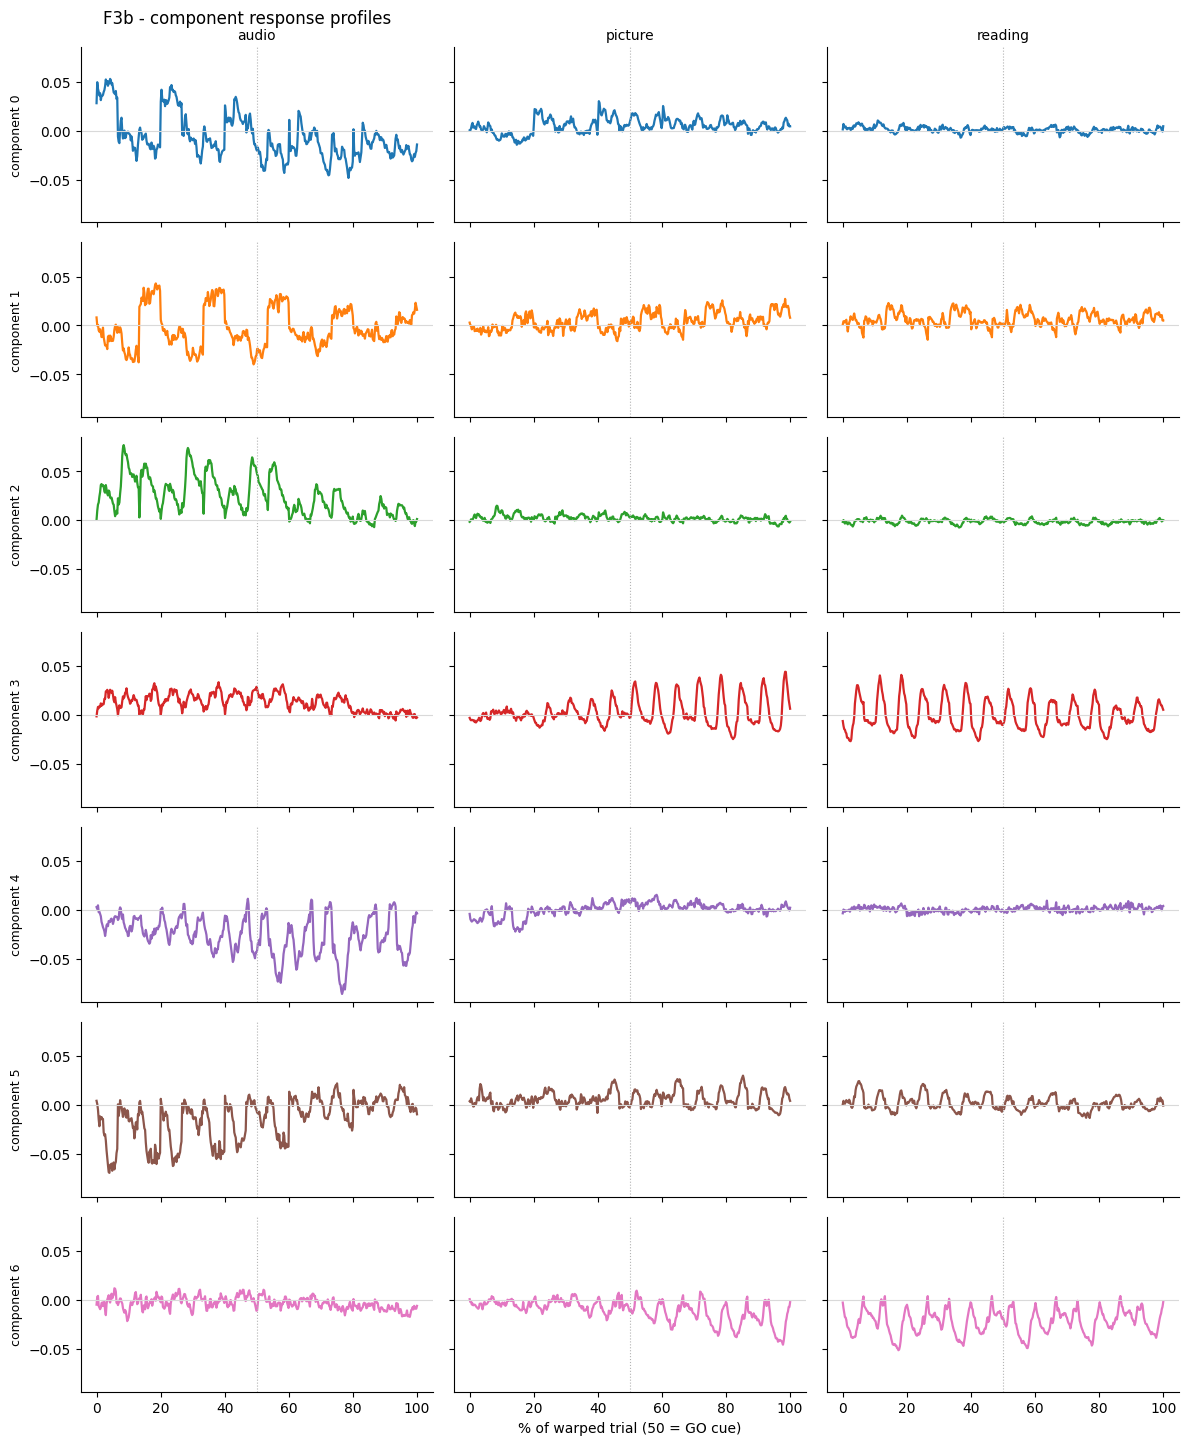

In [12]:
K = 7                       # knee of the held-out curve is 5->6; 7 chosen, validated in 236
W, G, C = D.convex_nmf(Xs, K, random_state=0, n_iter=300)
ve = 1 - ((Xs - D.reconstruct(Xs, W, G)) ** 2).sum() / (Xs ** 2).sum()
print(f"in-sample variance explained: {ve:.3f}")

t = np.linspace(0, 100, NT)
fig, axes = plt.subplots(K, 3, figsize=(12, 2.1 * K), sharex=True, sharey=True)
for j in range(K):
    for b, cond in enumerate(CONDS):
        a = axes[j, b]
        a.plot(t, C[j].reshape(3, NT)[b], lw=1.6, color=f"C{j}")
        a.axvline(50, color="0.7", lw=.8, ls=":")     # GO cue
        a.axhline(0, color="0.85", lw=.8)
        if j == 0: a.set_title(cond, fontsize=10)
        if b == 0: a.set_ylabel(f"component {j}", fontsize=9)
        a.spines[["top", "right"]].set_visible(False)
axes[-1, 1].set_xlabel("% of warped trial (50 = GO cue)")
fig.suptitle("F3b - component response profiles", x=.09, ha="left")
fig.tight_layout(); fig.savefig(OUT / "F3b_components.png", dpi=150, bbox_inches="tight"); plt.show()

## 3 - Electrodes are mixtures, not members

If most electrodes sit near a corner the discrete story was fine after all; if most sit in the middle it was not.

{
  "n": 1266,
  "frac_dominant": 0.035545023696682464,
  "frac_contested": 0.3080568720379147,
  "frac_no_majority": 0.6563981042654028,
  "median_top_weight": 0.4332056956062649
}


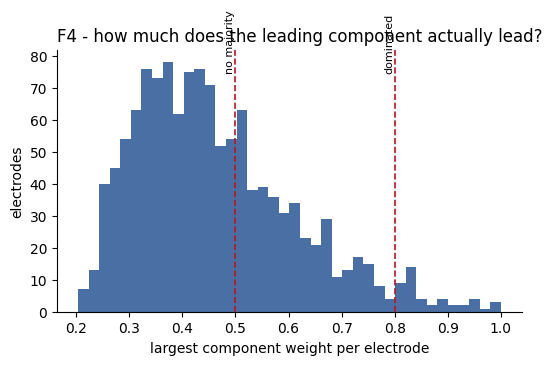

In [4]:
Gn = G / np.maximum(G.sum(1, keepdims=True), 1e-12)
print(json.dumps(D.mixture_summary(Gn), indent=2))

top = Gn.max(1)
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.hist(top, bins=40, color="#4a6fa5")
for v, lb in ((0.5, "no majority"), (0.8, "dominated")):
    ax.axvline(v, color="#c1121f", ls="--", lw=1.2)
    ax.text(v, ax.get_ylim()[1] * .92, lb, fontsize=8, rotation=90, ha="right")
ax.set_xlabel("largest component weight per electrode"); ax.set_ylabel("electrodes")
ax.set_title("F4 - how much does the leading component actually lead?", loc="left")
ax.spines[["top", "right"]].set_visible(False)
fig.savefig(OUT / "F4_mixture.png", dpi=150, bbox_inches="tight"); plt.show()

## 4 - Anatomy, coloured honestly

**Hue = leading component, saturation = how much it leads.** Contested cortex desaturates toward grey instead of being handed to an arbitrary winner - the whole point when a large share of electrodes have no majority component.

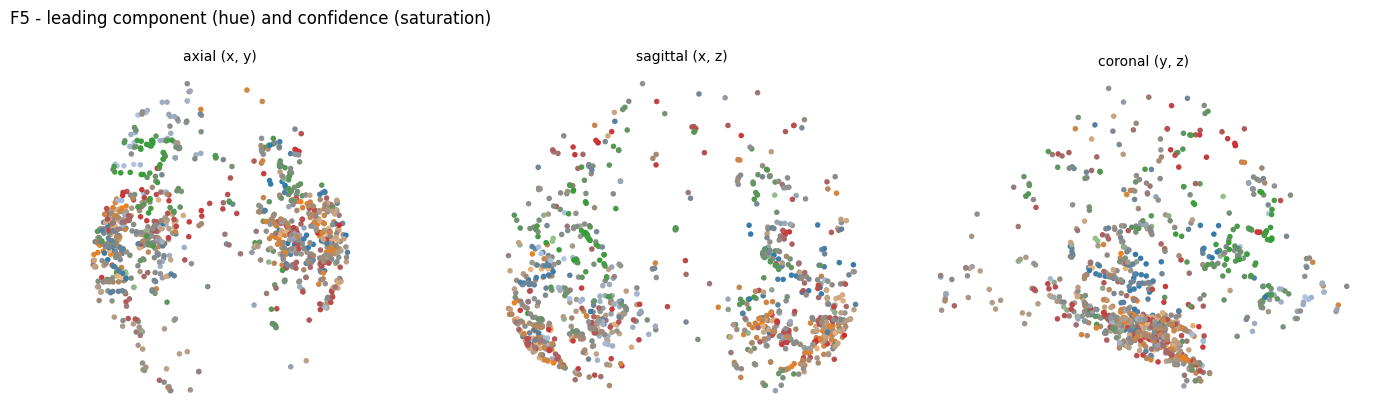

anatomical coherence of the hard argmax, for reference: 0.319 = 1.96x chance


In [5]:
PALETTE = plt.get_cmap("tab20").colors[:K]
rgb = D.soft_rgb(Gn, PALETTE)
ok  = ~np.isnan(XYZ).any(1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for a, (i, j, ti) in zip(axes, [(0, 1, "axial (x, y)"), (0, 2, "sagittal (x, z)"),
                                (1, 2, "coronal (y, z)")]):
    a.scatter(XYZ[ok, i], XYZ[ok, j], c=rgb[ok], s=16, lw=0)
    a.set_title(ti, fontsize=10); a.set_aspect("equal"); a.axis("off")
fig.suptitle("F5 - leading component (hue) and confidence (saturation)", x=.02, ha="left")
fig.tight_layout(); fig.savefig(OUT / "F5_soft_anatomy.png", dpi=150, bbox_inches="tight"); plt.show()

obs, ratio = D.spatial_coherence(Gn.argmax(1), XYZ)
print(f"anatomical coherence of the hard argmax, for reference: {obs:.3f} = {ratio:.2f}x chance")

## 5 - Which components share cortex?

Correlation between component loading maps. Positive pairs occupy the same tissue - exactly where a hard label is arbitrary.

In [6]:
names = [f"c{j}" for j in range(K)]
Cm = pd.DataFrame(np.corrcoef(Gn[ok].T), index=names, columns=names)
display(Cm.round(2))
iu = np.triu_indices(K, 1)
pairs = sorted(zip(Cm.to_numpy()[iu], zip(*iu)))
print(f"most co-located: c{pairs[-1][1][0]} & c{pairs[-1][1][1]}  r={pairs[-1][0]:+.2f}")

np.save(OUT / "G_loadings.npy", G); np.save(OUT / "components.npy", C)
lab.assign(**{f"w{j}": Gn[:, j] for j in range(K)}).to_csv(OUT / "electrode_loadings.csv", index=False)
print("saved ->", OUT)

,c0,c1,c2,c3,c4,c5,c6
c0,1.00,-0.22,-0.21,-0.23,-0.13,-0.04,-0.17
c1,-0.22,1.00,-0.13,-0.16,-0.09,-0.18,-0.14
c2,-0.21,-0.13,1.00,-0.18,-0.16,-0.17,-0.23
c3,-0.23,-0.16,-0.18,1.00,-0.27,-0.01,-0.16
c4,-0.13,-0.09,-0.16,-0.27,1.00,-0.11,-0.30
c5,-0.04,-0.18,-0.17,-0.01,-0.11,1.00,-0.12
c6,-0.17,-0.14,-0.23,-0.16,-0.30,-0.12,1.00


most co-located: c3 & c5  r=-0.01
saved -> outputs\clustering\decomposition


## 6 - Publish the K sweep, then refresh everything downstream

Everything above fits one K. The K control in the visualizer and the report needs the
same decomposition at every K in the range, written the way k-means and Ward already
write theirs, so run the cells below **after** `run_decomposition.py` and
`publish_decomposition.py` have produced a published cnmf run.

Order matters: the sweep writes the labels, stability reads those labels, centroids read
them too, and the coverage bundle reads everything. Running them out of order gives a
bundle describing a sweep that no longer exists.


In [ ]:
import subprocess, sys, shlex, time

def sh(cmd):
    """Run one of this folder's scripts and show its output.

    Uses sys.executable rather than a bare "python" so the cell runs against the same
    interpreter as the kernel, which is the difference between importing the project's
    functions and a confusing ImportError.
    """
    print(">", cmd, flush=True)
    t0 = time.time()
    p = subprocess.run([sys.executable] + shlex.split(cmd),
                       capture_output=True, text=True, encoding="utf-8", errors="replace")
    out = (p.stdout or "").strip()
    if out:
        print(out[-6000:])
    if p.returncode:
        print((p.stderr or "")[-4000:], file=sys.stderr)
        raise RuntimeError(f"{cmd} exited {p.returncode}")
    print(f"  [{time.time()-t0:.0f}s]", flush=True)
    print()

### 6a - convex NMF at every K

Fits K=5..12 on the same X the published run used and writes, into that run:
`cluster_labels_by_k.csv` (argmax per K), `loadings_by_k/` (the full weights) and
`components_by_k/`.

The loadings are the point. Convex NMF is graded - an electrode carries a weight on
every component and argmax is a summary of that. Saving only argmax would make every K
except the published one render as a hard partition, with no loading gate, no argmax
sizing and no grey ramp. `k_7` here is checked against the run's own `labels.csv`; it
should reproduce it exactly.


In [ ]:
for fs in ("concat_hg", "concat_rawds"):
    sh(f"sweep_decomposition.py --feature-set {fs}")

### 6b - stability at every K

`stability_summary.json` is written once, at the published K. Without this the results
table would show that one number under every K heading - a figure silently changing
meaning. Writes `stability_by_k/k_NN/` per run plus a `stability_by_k.csv` roll-up.

**This is the slow cell**: 6 runs x 8 K x 50 resampled fits. Drop to `--n-runs 20` for a
coarser pass while iterating. The script prints whether its own K matches the number
already published for that run; they should agree to within resampling noise.


In [ ]:
sh("sweep_stability.py --new-concat")           # add --n-runs 20 to go faster

### 6c - centroid chips at every K

`lf_centroids` already writes a `k_NN/` folder per K when a run has
`cluster_labels_by_k.csv` - the cnmf runs simply never had that file until 6a. `--force`
redraws so the cnmf runs pick up their new sweep.


In [ ]:
sh("make_missing_centroids.py --force")

### 6d - rebuild the coverage bundle

Last, because it reads everything above. `make_coverage_bundle.ok()` only accepts
git-tracked files, so anything written in this session has to be committed before the
bundle will reference it - otherwise the report falls back to "not published for this
run".


In [ ]:
sh("make_coverage_bundle.py")